### **LIBRARIES IMPORTING**

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import keras_cv
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

: 

# **METRICS**

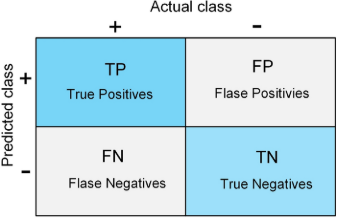

TP (True Positives): Dự đoán là lớp dương (mắc bệnh) và đúng

FP (False Positives): Dự đoán là lớp dương (mắc bệnh) và sai (đúng phải là không mắc bệnh)

TN (True Negatives): Dự đoán là lớp âm (không mắc bệnh) và đúng

FN (False Negatives): Dự đoán là lớp âm (không mắc bệnh) và sai (đúng phải là mắc bệnh)

In [ ]:
def metrics(y_true, y_pred):
    print(np.sum((y_true == 0) & (y_pred == 0)))
    print(np.sum((y_true == 0) & (y_pred == 1)))
    print(np.sum((y_true == 1) & (y_pred == 0)))
    print(np.sum((y_true == 1) & (y_pred == 1)))
    

## **Accuracy**

$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

In [ ]:
from sklearn.metrics import accuracy_score

## **Precision**

Precision đo lường tỷ lệ các dự đoán dương (Positive) thực sự đúng, tức là trong số các mẫu được dự đoán là Positive, có bao nhiêu mẫu thực sự là Positive.

$\text{Precision} = \frac{TP}{TP + FP}$

In [ ]:
from sklearn.metrics import precision_score

## **FDR**

FDR dùng để đo tỷ lệ dự đoán dương nhưng thực tế lại âm.

$\text{FDR} = \frac{FP}{TP + FP} = 1 - \text{Precision}$

In [ ]:
def fdr(y_true, y_pred):
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    
    fdr_ = FP / (FP + TP) if (FP + TP) > 0 else 0
    
    return fdr_

## **Recall**

Recall đo lường khả năng mô hình nhận diện đúng các mẫu dương (positive cases).

$\text{Recall} = \frac{TP}{TP + FN}$

In [ ]:
from sklearn.metrics import recall_score

## **FNR**

FNR đo tỷ lệ các mẫu dương thực sự nhưng bị mô hình phân loại sai thành âm tính

$\text{FNR} = \frac{FN}{TP + FN} = 1 - \text{Recall}$

In [ ]:
def fnr(y_true, y_pred):
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))
    
    fnr_ = FN / (FN + TP) if (FN + TP) > 0 else 0
    
    return fnr_

## **Specificity**

Specificity đo lường khả năng mô hình nhận diện đúng các mẫu âm

$\text{Specificity} = \frac{TN}{TN + FP}$

In [ ]:
def specificity(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    
    specificity_ = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return specificity_

## **NPV**

NPV đo lường xác suất một mẫu được dự đoán là âm tính thực sự là âm tính

$\text{NPV} = \frac{TN}{TN + FN}$

In [ ]:
def npv(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    npv_ = TN / (TN + FN) if (TN + FN) > 0 else 0
    
    return npv_

## **F1-Score**

F1-score giúp cân bằng giữa Precision và Recall, đặc biệt hữu ích khi dữ liệu bị lệch (imbalanced data). 

$\text{F1-score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$

In [ ]:
from sklearn.metrics import f1_score

## **BAcc**

Balanced Accuracy (BAcc) là trung bình cộng của Recall (TPR) và Specificity (TNR), hữu ích khi làm việc với dữ liệu mất cân bằng, giúp đánh giá hiệu suất mô hình một cách công bằng giữa hai lớp.

$\text{BAcc} = \frac{\text{Recall} + \text{Specificity}}{2} = \frac{ \frac{TP}{TP + FN} + \frac{TN}{TN + FP} }{2}$

In [ ]:
from sklearn.metrics import balanced_accuracy_score

## **AUC**

AUC là diện tích dưới đường cong ROC (Receiver Operating Characteristic). Nó đo lường khả năng phân biệt giữa hai lớp của mô hình. AUC dao động từ 0.5 (đoán ngẫu nhiên) đến 1.0 (mô hình hoàn hảo). Giá trị càng cao, mô hình càng có khả năng phân biệt tốt giữa hai lớp.

$\text{AUC} = \int_{0}^{1} \text{TPR}(x) \, d\text{FPR}(x)$

In [ ]:
from sklearn.metrics import roc_auc_score

## **MCC**

Matthews Correlation Coefficient (MCC) đo lường chất lượng của mô hình phân loại nhị phân, cân bằng giữa tất cả các loại lỗi (TP, FP, TN, FN).

MCC có giá trị từ -1 đến 1:
* MCC = 1: Dự đoán hoàn hảo.
* MCC = 0: Dự đoán ngẫu nhiên.
* MCC = -1: Dự đoán hoàn toàn sai.

$\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$

In [ ]:
from sklearn.metrics import matthews_corrcoef

In [ ]:
x_train_cxr = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/train/images.npy')

x_test_cxr = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/test/images.npy')

In [ ]:
y_train = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/train/labels.npy')
y_test = np.load('/kaggle/input/pneumonia-detection-datasets/chest-xray/test/labels.npy')

In [ ]:
import numpy as np

x_train_vit = np.load('/kaggle/input/kltn-feature/ViT/ViT/X-ray/vit_train.npy')
x_test_vit  = np.load('/kaggle/input/kltn-feature/ViT/ViT/X-ray/vit_test.npy')

x_train_rad = np.load('/kaggle/input/kltn-feature/Rad/Rad/X-ray/rad_train.npy')
x_test_rad  = np.load('/kaggle/input/kltn-feature/Rad/Rad/X-ray/rad_test.npy')

x_train_sta = np.load('/kaggle/input/kltn-feature/Sta/Sta/X-ray/sta_train.npy')
x_test_sta  = np.load('/kaggle/input/kltn-feature/Sta/Sta/X-ray/sta_test.npy')

x_train_wst = np.load('/kaggle/input/kltn-feature/WST/WST/X-ray/wst_train.npy')
x_test_wst  = np.load('/kaggle/input/kltn-feature/WST/WST/X-ray/wst_test.npy')

In [ ]:
x_train_radsta = np.concatenate([x_train_rad, x_train_sta], axis=1)
x_test_radsta  = np.concatenate([x_test_rad, x_test_sta], axis=1)

print(x_train_radsta.shape)
print(x_test_radsta.shape)

In [ ]:
from sklearn.model_selection import train_test_split

x_train_vit, x_val_vit, \
x_train_radsta, x_val_radsta, \
x_train_wst, x_val_wst, \
y_train, y_val = train_test_split(
    x_train_vit, x_train_radsta, x_train_wst, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

In [ ]:
print(x_train_vit.shape)
print(x_train_rad.shape)
print(x_train_sta.shape)
print(x_train_wst.shape)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_wst = PCA(n_components=0.95)
x_train_wst = pca_wst.fit_transform(x_train_wst)
x_val_wst   = pca_wst.transform(x_val_wst)
x_test_wst  = pca_wst.transform(x_test_wst)

pca_vit = PCA(n_components=0.95)
x_train_vit = pca_vit.fit_transform(x_train_vit)
x_val_vit   = pca_vit.transform(x_val_vit)
x_test_vit  = pca_vit.transform(x_test_vit)


print(x_train_wst.shape)
print(x_train_vit.shape)

In [ ]:
print(x_train_vit.shape)
print(x_train_rad.shape)
print(x_train_sta.shape)
print(x_train_wst.shape)

In [ ]:
import torch
import torch.nn as nn

class GatedFusion(nn.Module):

    def __init__(self, vit_dim, radsta_dim, wst_dim, hidden_dim=64, num_classes=2):
        super().__init__()

        # projection
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        self.radsta_proj = nn.Linear(radsta_dim, hidden_dim)
        self.wst_proj = nn.Linear(wst_dim, hidden_dim)

        # normalization
        self.norm_vit = nn.LayerNorm(hidden_dim)
        self.norm_radsta = nn.LayerNorm(hidden_dim)
        self.norm_wst = nn.LayerNorm(hidden_dim)

        # gate
        self.gate_vit = nn.Linear(hidden_dim, hidden_dim)
        self.gate_radsta = nn.Linear(hidden_dim, hidden_dim)
        self.gate_wst = nn.Linear(hidden_dim, hidden_dim)

        self.sigmoid = nn.Sigmoid()

        self.dropout = nn.Dropout(0.3)

        # classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, vit, radsta, wst, return_feature=False):

        vit = self.norm_vit(self.vit_proj(vit))
        radsta = self.norm_radsta(self.radsta_proj(radsta))
        wst = self.norm_wst(self.wst_proj(wst))
    
        # ==========================================
        # GATES
        # ==========================================
    
        g_vit = self.sigmoid(self.gate_vit(vit))
        g_radsta = self.sigmoid(self.gate_radsta(radsta))
        g_wst = self.sigmoid(self.gate_wst(wst))
    
        vit = vit * (1 + g_vit)
        radsta = radsta * (1 + g_radsta)
        wst = wst * (1 + g_wst)

        # ==========================================
        # FUSION
        # ==========================================
    
        fused = (vit + radsta + wst) / 3
    
        fused = self.dropout(fused)
    
        # ==========================================
        # GATE WEIGHTS FOR VISUALIZATION
        # ==========================================
    
        gate_weights = torch.stack(
            [
                g_vit.mean(dim=1),
                g_radsta.mean(dim=1),
                g_wst.mean(dim=1)
            ],
            dim=1
        )
    
        # shape:
        # [batch, 3]
    
        # ==========================================
        # RETURN FEATURE
        # ==========================================
    
        if return_feature:
    
            return fused, gate_weights
    
        # ==========================================
        # CLASSIFICATION
        # ==========================================
    
        out = self.classifier(fused)
    
        return out

In [ ]:
import torch
from torch.utils.data import Dataset

class FusionDataset(Dataset):

    def __init__(self, vit, radsta, wst, labels):

        self.vit = torch.tensor(vit, dtype=torch.float32)
        self.radsta = torch.tensor(radsta, dtype=torch.float32)
        self.wst = torch.tensor(wst, dtype=torch.float32)

        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.vit)

    def __getitem__(self, idx):

        return (
            self.vit[idx],
            self.radsta[idx],
            self.wst[idx],
            self.labels[idx]
        )

In [ ]:
import torch
from torch.utils.data import DataLoader

# train dataset
train_dataset = FusionDataset(
    x_train_vit,
    x_train_radsta,
    x_train_wst,
    y_train
)

# val dataset
val_dataset = FusionDataset(
    x_val_vit,
    x_val_radsta,
    x_val_wst,
    y_val
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
print("ViT dim:", x_train_vit.shape)
print("RadSta dim:", x_train_radsta.shape)
print("WST dim:", x_train_wst.shape)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GatedFusion(
    x_train_vit.shape[1],
    x_train_radsta.shape[1],
    x_train_wst.shape[1]
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
patience = 2
counter = 0

num_epochs = 15

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for vit, radsta, wst, labels in train_loader:
        vit = vit.to(device)
        radsta = radsta.to(device)
        wst = wst.to(device)
        labels = labels.to(device)

        outputs = model(vit, radsta, wst)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for vit, radsta, wst, labels in val_loader:
            vit = vit.to(device)
            radsta = radsta.to(device)
            wst = wst.to(device)
            labels = labels.to(device)

            outputs = model(vit, radsta, wst)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    # lưu history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_gatedfusion.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

In [ ]:
plt.figure()

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.show()

In [ ]:
def extract_fused_feature(
    model,
    vit,
    radsta,
    wst,
    batch_size=64
):

    device = next(model.parameters()).device

    dataset = FusionDataset(
        vit,
        radsta,
        wst,
        [0] * len(vit)
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size
    )

    model.eval()

    fused_features = []

    with torch.no_grad():

        for vit, radsta, wst, _ in loader:

            vit = vit.to(device)
            radsta = radsta.to(device)
            wst = wst.to(device)

            # ===================================
            # NOW RETURNS 2 VALUES
            # ===================================

            fused, gate_weights = model(
                vit,
                radsta,
                wst,
                return_feature=True
            )

            fused_features.append(
                fused.cpu()
            )

    fused_features = torch.cat(
        fused_features,
        dim=0
    )

    return fused_features.numpy()

In [ ]:
print(x_test_vit.shape)
print(x_test_rad.shape)
print(x_test_sta.shape)
print(x_test_wst.shape)

In [ ]:
x_train_fused = extract_fused_feature(
    model,
    x_train_vit,
    x_train_radsta,
    x_train_wst
)

x_val_fused = extract_fused_feature(
    model,
    x_val_vit,
    x_val_radsta,
    x_val_wst
)

x_test_fused = extract_fused_feature(
    model,
    x_test_vit,
    x_test_radsta,
    x_test_wst
)

print(x_train_fused.shape)
print(x_test_fused.shape)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_train_fused)

plt.scatter(X_pca[y_train==0,0], X_pca[y_train==0,1], alpha=0.3)
plt.scatter(X_pca[y_train==1,0], X_pca[y_train==1,1], alpha=0.3)
plt.show()

In [ ]:
# from collections import Counter
# n_samples = len(y_train)

# # Đếm số lượng mẫu trong từng lớp
# class_counts = Counter(y_train)  # Tạo dictionary {0: số lượng, 1: số lượng}
# n_classes = len(class_counts)  # Số lớp (ở đây là 2: 0 và 1)

# # Tính trọng số cho từng lớp
# class_weights = {cls: n_samples / (n_classes * count) for cls, count in class_counts.items()}

# # In kết quả
# print("Số lượng mẫu mỗi lớp:", class_counts)
# print("Trọng số tính toán:", class_weights)

# print(y_train.shape)
# print("Images for Train", np.shape(x_train_fused))

# print(y_test.shape)
# param_grid = {
#     'n_estimators': [300, 500],
#     'max_depth': [4, 5, 6],
#     'criterion': ['entropy'],
#     'min_samples_split': [20, 30, 40],
#     'min_samples_leaf': [6, 8, 10],
#     'max_features': ['sqrt', 'log2']
# }

# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=42, class_weight = class_weights), 
#     param_grid=param_grid, 
#     cv=5, 
#     scoring='accuracy', 
#     verbose=4
# )

# grid_search.fit(x_train_fused, y_train)

# print("Best Parameters:", grid_search.best_params_)
# # rf_fused = RandomForestClassifier(
# #     n_estimators=300,        # số cây
# #     max_depth=None,          # để cây tự học
# #     min_samples_split=2,
# #     min_samples_leaf=1,
# #     max_features="sqrt",     # rất quan trọng
# #     class_weight="balanced", # dữ liệu X-ray thường lệch lớp
# #     random_state=42,
# #     n_jobs=-1
# # )

# # rf_fused.fit(x_train_vit_scaled, y_train)
# # y_pred = rf_fused.predict(x_test_vit_scaled)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## **KNN**

In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=4
)

grid_knn.fit(x_train_fused, y_train)

print("Best KNN params:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_

from sklearn.metrics import accuracy_score, classification_report

y_val_pred = best_knn.predict(x_val_fused)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

import numpy as np

X_trainval = np.concatenate([x_train_fused, x_val_fused])
y_trainval = np.concatenate([y_train, y_val])

best_knn.fit(X_trainval, y_trainval)

## **Logistic Regression**

In [ ]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    param_grid_lr,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=4
)

grid_lr.fit(x_train_fused, y_train)
print("Best LR params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

from sklearn.metrics import accuracy_score, classification_report

y_val_pred = best_lr.predict(x_val_fused)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

import numpy as np

X_trainval = np.concatenate([x_train_fused, x_val_fused])
y_trainval = np.concatenate([y_train, y_val])

best_lr.fit(X_trainval, y_trainval)


## **Linear SVM**

In [ ]:
param_grid_svm_linear = {
    'C': [0.01, 0.1, 1, 10]
}

grid_svm_linear = GridSearchCV(
    SVC(
        kernel='linear',
        class_weight='balanced'
    ),
    param_grid_svm_linear,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=4
)

grid_svm_linear.fit(x_train_fused, y_train)
print("Best Linear SVM params:", grid_svm_linear.best_params_)

best_svm_linear = grid_svm_linear.best_estimator_

from sklearn.metrics import accuracy_score, classification_report

y_val_pred = best_svm_linear.predict(x_val_fused)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

import numpy as np

X_trainval = np.concatenate([x_train_fused, x_val_fused])
y_trainval = np.concatenate([y_train, y_val])

best_svm_linear.fit(X_trainval, y_trainval)

## **RBF-SVM**

In [ ]:
param_grid_svm_rbf = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid_svm_rbf = GridSearchCV(
    SVC(
        kernel='rbf',
        class_weight='balanced'
    ),
    param_grid_svm_rbf,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=1,
    verbose=4
)

grid_svm_rbf.fit(x_train_fused, y_train)
print("Best RBF-SVM params:", grid_svm_rbf.best_params_)

best_svm_rbf = grid_svm_rbf.best_estimator_

from sklearn.metrics import accuracy_score, classification_report

y_val_pred = best_svm_rbf.predict(x_val_fused)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

import numpy as np

X_trainval = np.concatenate([x_train_fused, x_val_fused])
y_trainval = np.concatenate([y_train, y_val])

best_svm_rbf.fit(X_trainval, y_trainval)

# **MLP**

In [ ]:
# from sklearn.neural_network import MLPClassifier
# from sklearn.model_selection import GridSearchCV

# param_grid_mlp = {
#     'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
#     'activation': ['relu', 'tanh'],
#     'solver': ['adam'],
#     'alpha': [1e-5, 1e-4, 1e-3],
#     'learning_rate_init': [0.001, 0.01],
#     'learning_rate': ['constant', 'adaptive'],
#     'max_iter': [500],
#     'early_stopping': [True]
# }
# grid_mlp = GridSearchCV(
#     MLPClassifier(random_state=42),
#     param_grid_mlp,
#     cv=5,
#     scoring='balanced_accuracy',
#     n_jobs=1,
#     verbose=4
# )

# grid_mlp.fit(x_train_fused, y_train)

# print("Best MLP params:", grid_mlp.best_params_)

# best_mlp = grid_mlp.best_estimator_

# from sklearn.metrics import accuracy_score, classification_report

# y_val_pred = best_mlp.predict(x_val_fused)

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
# print(classification_report(y_val, y_val_pred))

# import numpy as np

# X_trainval = np.concatenate([x_train_fused, x_val_fused])
# y_trainval = np.concatenate([y_train, y_val])

# best_mlp.fit(X_trainval, y_trainval)

In [ ]:
def evaluate_model(y_true, y_pred, name="Model"):
    print(f"\n{name}")
    print('accuracy = {}'.format(accuracy_score(y_test, y_pred)))
    print('precision = {}'.format(precision_score(y_test, y_pred)))
    print('FDR = {}'.format(fdr(y_test, y_pred)))
    print('recall = {}'.format(recall_score(y_test, y_pred)))
    print('FNR = {}'.format(fnr(y_test, y_pred)))
    print('specificity = {}'.format(specificity(y_test, y_pred)))
    print('NPV = {}'.format(npv(y_test, y_pred)))
    print('f1-score = {}'.format(f1_score(y_test, y_pred)))
    print('BAcc = {}'.format(balanced_accuracy_score(y_test, y_pred)))
    print('AUC = {}'.format(roc_auc_score(y_test, y_pred)))
    print('MCC = {}'.format(matthews_corrcoef(y_test, y_pred)))

In [ ]:
models = {
    "KNN": grid_knn.best_estimator_,
    "Logistic Regression": grid_lr.best_estimator_,
    "Linear SVM": grid_svm_linear.best_estimator_,
    "RBF-SVM": grid_svm_rbf.best_estimator_,
    # "MLP": grid_mlp.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(x_test_fused)
    evaluate_model(y_test, y_pred, name)

In [ ]:
# best_rf = grid_search.best_estimator_

# y_pred = best_rf.predict(x_test_fused)
# print('accuracy = {}'.format(accuracy_score(y_test, y_pred)))
# print('precision = {}'.format(precision_score(y_test, y_pred)))
# print('FDR = {}'.format(fdr(y_test, y_pred)))
# print('recall = {}'.format(recall_score(y_test, y_pred)))
# print('FNR = {}'.format(fnr(y_test, y_pred)))
# print('specificity = {}'.format(specificity(y_test, y_pred)))
# print('NPV = {}'.format(npv(y_test, y_pred)))
# print('f1-score = {}'.format(f1_score(y_test, y_pred)))
# print('BAcc = {}'.format(balanced_accuracy_score(y_test, y_pred)))
# print('AUC = {}'.format(roc_auc_score(y_test, y_pred)))
# print('MCC = {}'.format(matthews_corrcoef(y_test, y_pred)))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(x_test_fused)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    plt.show()